# Laboratorio 6  
## Desbalance + SMOTE + aprendizaje no supervisado (PCA/KMeans)

**Objetivo general.**  
En este laboratorio estudiarás dos problemas habituales en proyectos reales de ML tabular:

1. cómo entrenar un clasificador cuando la clase positiva es minoritaria,
2. cómo usar **SMOTE** sin contaminar validación ni test,
3. cómo explorar la estructura del dataset con **PCA** y **KMeans**.


**Productos esperados.**
- comparación de métricas baseline vs SMOTE,
- matrices de confusión comentadas,
- selección razonada de `k`,
- interpretación de clusters en términos de negocio.


In [1]:
# Instala imbalanced-learn (necesario para SMOTE)
%pip -q install imbalanced-learn

In [2]:
# Librerías: preprocesamiento, SMOTE, PCA y KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

In [ ]:
# Montaje de Google Drive (solo Colab; no necesario en local)
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Carga del dataset completo

El notebook funciona de dos maneras:

- **Modo A:** usas uno de los CSV completos del paquete y lo lees desde Colab.
- **Modo B:** generas internamente un dataset sintético equivalente para practicar sin archivos externos.

**Archivos esperados del paquete:**
- `lab6_smote_pca_kmeans_dataset_completo.csv`
- `lab6_smote_pca_kmeans_dataset_completo_alt.csv`

> En ambos casos, el split `train / valid / test` se crea más abajo con `train_test_split`.


In [3]:
USE_FILE = True
FILE_PATH = Path("../datasets/lab06/lab6_smote_pca_kmeans_dataset_completo.csv")
EXPORT_SPLITS = False  # cambia a True solo si quieres guardar los cortes generados por el notebook

In [4]:
# Genera dataset sintético o lee el CSV real (USE_FILE)
def generate_customer_dataset(n=1800, seed=42, intercept=-1.8):
    rng = np.random.default_rng(seed)
    segments = rng.choice(["Loyal", "Digital", "AtRisk"], size=n, p=[0.48, 0.30, 0.22])
    rows = []

    for i, seg in enumerate(segments, 1):
        if seg == "Loyal":
            tenure = int(np.clip(rng.normal(34, 11), 1, 60))
            monthly_spend = round(np.clip(rng.normal(49, 12), 15, 130), 2)
            support_tickets = int(np.clip(rng.poisson(1.3), 0, 10))
            late_payments = int(np.clip(rng.poisson(0.35), 0, 7))
            num_logins_30d = int(np.clip(rng.normal(23, 5), 3, 40))
            satisfaction = round(np.clip(rng.normal(8.1, 0.8), 1, 10), 1)
            streaming_hours = round(np.clip(rng.normal(9.0, 3.0), 0, 30), 1)
            contract = rng.choice(["annual", "biennial"], p=[0.65, 0.35])
            payment = rng.choice(["card", "debit", "bank"], p=[0.58, 0.22, 0.20])
            region = rng.choice(["north", "center", "south"], p=[0.30, 0.45, 0.25])
            app = rng.choice([0, 1], p=[0.25, 0.75])
            security = rng.choice([0, 1], p=[0.40, 0.60])

        elif seg == "Digital":
            tenure = int(np.clip(rng.normal(17, 8), 1, 48))
            monthly_spend = round(np.clip(rng.normal(64, 15), 20, 140), 2)
            support_tickets = int(np.clip(rng.poisson(2.0), 0, 12))
            late_payments = int(np.clip(rng.poisson(0.7), 0, 8))
            num_logins_30d = int(np.clip(rng.normal(29, 5), 6, 45))
            satisfaction = round(np.clip(rng.normal(6.8, 1.0), 1, 10), 1)
            streaming_hours = round(np.clip(rng.normal(12.5, 4.0), 0, 35), 1)
            contract = rng.choice(["monthly", "annual"], p=[0.72, 0.28])
            payment = rng.choice(["card", "wallet", "debit"], p=[0.42, 0.40, 0.18])
            region = rng.choice(["north", "center", "south"], p=[0.33, 0.39, 0.28])
            app = rng.choice([0, 1], p=[0.08, 0.92])
            security = rng.choice([0, 1], p=[0.58, 0.42])

        else:  # AtRisk
            tenure = int(np.clip(rng.normal(11, 7), 1, 36))
            monthly_spend = round(np.clip(rng.normal(80, 18), 20, 160), 2)
            support_tickets = int(np.clip(rng.poisson(4.0), 0, 14))
            late_payments = int(np.clip(rng.poisson(2.0), 0, 9))
            num_logins_30d = int(np.clip(rng.normal(11, 4), 0, 30))
            satisfaction = round(np.clip(rng.normal(4.9, 1.2), 1, 10), 1)
            streaming_hours = round(np.clip(rng.normal(5.0, 2.5), 0, 25), 1)
            contract = rng.choice(["monthly", "annual"], p=[0.88, 0.12])
            payment = rng.choice(["cash", "wallet", "card"], p=[0.38, 0.34, 0.28])
            region = rng.choice(["north", "center", "south"], p=[0.28, 0.34, 0.38])
            app = rng.choice([0, 1], p=[0.58, 0.42])
            security = rng.choice([0, 1], p=[0.78, 0.22])

        logit = (
            intercept
            - 0.05 * tenure
            + 0.025 * monthly_spend
            + 0.55 * support_tickets
            + 0.65 * late_payments
            - 0.08 * num_logins_30d
            - 0.60 * satisfaction
            - 0.04 * streaming_hours
            + (0.65 if contract == "monthly" else -0.30)
            + (0.35 if payment in ["cash", "wallet"] else -0.10)
            + (0.25 if app == 0 else -0.10)
            + (0.18 if security == 0 else -0.08)
        )
        p = 1 / (1 + np.exp(-logit))
        churn = int(rng.random() < p)

        rows.append({
            "customer_id": i,
            "tenure_months": tenure,
            "monthly_spend": monthly_spend,
            "support_tickets": support_tickets,
            "late_payments": late_payments,
            "num_logins_30d": num_logins_30d,
            "satisfaction_score": satisfaction,
            "streaming_hours_week": streaming_hours,
            "contract_type": contract,
            "payment_method": payment,
            "region": region,
            "uses_mobile_app": app,
            "uses_addon_security": security,
            "churn": churn,
        })

    return pd.DataFrame(rows)

if USE_FILE and FILE_PATH.exists():
    df = pd.read_csv(FILE_PATH)
else:
    df = generate_customer_dataset()

df.head()

,customer_id,tenure_months,monthly_spend,support_tickets,late_payments,num_logins_30d,satisfaction_score,streaming_hours_week,contract_type,payment_method,region,uses_mobile_app,uses_addon_security,churn
0,1,35,48.54,0,1,25,5.7,8.3,monthly,card,north,1,1,0
1,2,30,43.58,2,0,24,7.0,9.6,annual,debit,north,1,1,0
2,3,15,101.83,3,0,10,5.2,4.2,monthly,cash,center,0,1,1
3,4,16,70.64,3,1,29,7.8,4.7,monthly,card,north,1,1,0
4,5,44,54.81,3,0,18,8.6,11.6,biennial,bank,south,1,0,0


Shape: (1800, 14)
Porcentaje de churn: 11.89 %


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1800.0,NaN,NaN,NaN,900.5,519.75956,1.0,450.75,900.5,1350.25,1800.0
tenure_months,1800.0,NaN,NaN,NaN,23.477222,13.625155,1.0,13.0,21.5,33.0,60.0
monthly_spend,1800.0,NaN,NaN,NaN,61.318244,19.230268,17.66,47.42,58.94,73.025,130.82
support_tickets,1800.0,NaN,NaN,NaN,2.135556,1.832467,0.0,1.0,2.0,3.0,12.0
late_payments,1800.0,NaN,NaN,NaN,0.840556,1.111674,0.0,0.0,0.0,1.0,7.0
num_logins_30d,1800.0,NaN,NaN,NaN,21.395556,8.039451,1.0,16.0,22.0,27.0,45.0
satisfaction_score,1800.0,NaN,NaN,NaN,7.0775,1.563529,1.6,6.1,7.4,8.2,10.0
streaming_hours_week,1800.0,NaN,NaN,NaN,9.204833,4.222835,0.0,6.2,9.0,11.7,26.3
contract_type,1800,3,annual,775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,1800,5,card,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


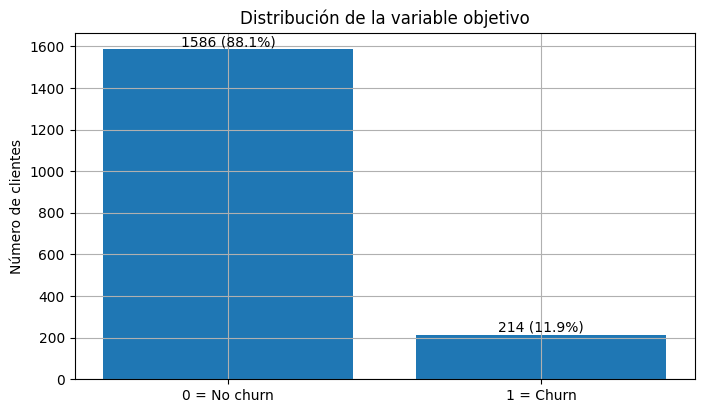

In [5]:
# Tamaño del dataset y % de churn (mide el desbalance)
print("Shape:", df.shape)
print("Porcentaje de churn:", round(df["churn"].mean() * 100, 2), "%")
display(df.describe(include="all").transpose())

class_counts = df["churn"].value_counts().sort_index()
plt.bar(["0 = No churn", "1 = Churn"], class_counts.values)
for i, c in enumerate(class_counts.values):
    plt.text(i, c + 15, f"{c} ({c/len(df):.1%})", ha="center")
plt.title("Distribución de la variable objetivo")
plt.ylabel("Número de clientes")
plt.show()

### Pregunta de análisis
Antes de modelar, responde:

- ¿la clase positiva representa un problema serio de desbalance?
- si usas solo accuracy, ¿qué error de interpretación podrías cometer?

**Respuestas — Pregunta de análisis**

- **¿Hay desbalance serio?** Sí. La clase positiva (churn=1) es claramente minoritaria respecto a la negativa, por lo que el modelo tiende a favorecer la clase mayoritaria.
- **Riesgo de usar solo accuracy:** un modelo que prediga "no churn" para casi todos obtendría un accuracy alto simplemente porque la mayoría no abandona, aunque no detecte a ningún cliente en riesgo. Por eso hay que mirar recall y F1 de la clase minoritaria, no solo accuracy.


## 2. Split estratificado y preparación del problema

In [6]:
# Split estratificado train/valid/test (mantiene proporción de clases)
train_df, temp_df = train_test_split(
    df, test_size=0.4, stratify=df["churn"], random_state=RANDOM_STATE
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["churn"], random_state=RANDOM_STATE
)

feature_cols = [
    "tenure_months", "monthly_spend", "support_tickets", "late_payments",
    "num_logins_30d", "satisfaction_score", "streaming_hours_week",
    "contract_type", "payment_method", "region", "uses_mobile_app", "uses_addon_security"
]
target_col = "churn"

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_valid, y_valid = valid_df[feature_cols], valid_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print("Dataset original:", df.shape)
print("Train:", train_df.shape, "Churn rate:", round(y_train.mean(), 4))
print("Valid:", valid_df.shape, "Churn rate:", round(y_valid.mean(), 4))
print("Test :", test_df.shape, "Churn rate:", round(y_test.mean(), 4))

if EXPORT_SPLITS:
    train_df.to_csv("/content/train_generado_desde_codigo.csv", index=False)
    valid_df.to_csv("/content/valid_generado_desde_codigo.csv", index=False)
    test_df.to_csv("/content/test_generado_desde_codigo.csv", index=False)
    print("Se exportaron los tres cortes en /content/")
else:
    print("No se exportan archivos train/valid/test porque el laboratorio trabaja con dataset completo + split en código.")


Dataset original: (1800, 14)
Train: (1080, 14) Churn rate: 0.1185
Valid: (360, 14) Churn rate: 0.1194
Test : (360, 14) Churn rate: 0.1194
No se exportan archivos train/valid/test porque el laboratorio trabaja con dataset completo + split en código.


### Nota metodológica

- **Nunca** debes aplicar SMOTE antes de separar el dataset.
- El flujo correcto es:
  1. cargar el CSV completo,
  2. hacer el split,
  3. ajustar el preprocesamiento con entrenamiento,
  4. aplicar SMOTE solo en el pipeline de entrenamiento,
  5. evaluar en validación y test sin sobremuestreo.


In [7]:
# Preprocesa: imputa + escala numéricas, one-hot a categóricas
numeric_features = [
    "tenure_months", "monthly_spend", "support_tickets", "late_payments",
    "num_logins_30d", "satisfaction_score", "streaming_hours_week"
]
categorical_features = [
    "contract_type", "payment_method", "region", "uses_mobile_app", "uses_addon_security"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

## 3. Modelo baseline sin balanceo

En esta primera corrida no hacemos nada especial para compensar la clase minoritaria.
La idea es medir una referencia inicial.

In [8]:
# Modelo baseline (sin balanceo) como referencia
def evaluate_model(model, X, y_true, name="modelo"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
    }, y_pred, y_prob

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

baseline_model.fit(X_train, y_train)

baseline_valid, _, _ = evaluate_model(baseline_model, X_valid, y_valid, "Baseline valid")
baseline_test, baseline_pred, baseline_prob = evaluate_model(baseline_model, X_test, y_test, "Baseline test")

pd.DataFrame([baseline_valid, baseline_test]).round(4)

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,Baseline valid,0.9444,0.7447,0.8140,0.7778,0.9719
1,Baseline test,0.9500,0.7551,0.8605,0.8043,0.9755


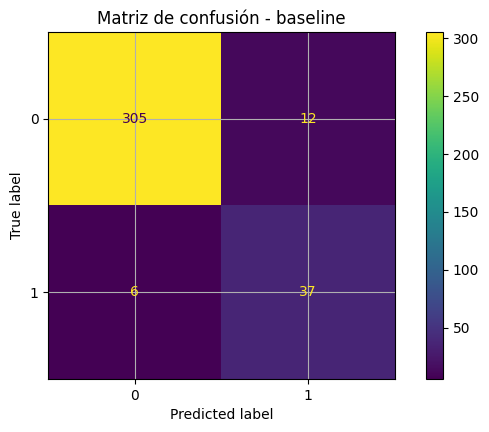

In [9]:
# Matriz de confusión del baseline
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred)
plt.title("Matriz de confusión - baseline")
plt.show()

## 4. Modelo con SMOTE

**Regla crítica:** SMOTE se aplica **solo** dentro del pipeline de entrenamiento.
No debe ejecutarse antes del split ni sobre valid/test.

In [10]:
# Mismo modelo pero con SMOTE dentro del pipeline de train
smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

smote_model.fit(X_train, y_train)

smote_valid, _, _ = evaluate_model(smote_model, X_valid, y_valid, "SMOTE valid")
smote_test, smote_pred, smote_prob = evaluate_model(smote_model, X_test, y_test, "SMOTE test")

pd.DataFrame([smote_valid, smote_test]).round(4)

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,SMOTE valid,0.900,0.5493,0.9070,0.6842,0.9710
1,SMOTE test,0.925,0.6212,0.9535,0.7523,0.9754


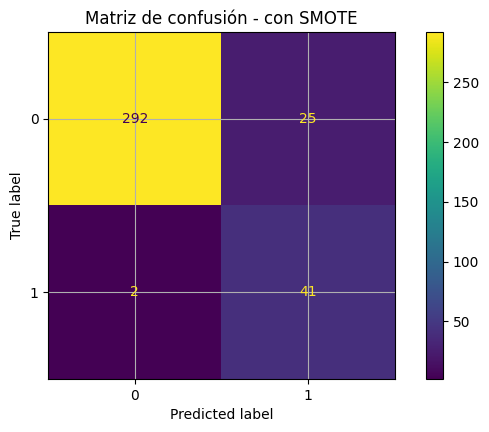

In [11]:
# Matriz de confusión con SMOTE
ConfusionMatrixDisplay.from_predictions(y_test, smote_pred)
plt.title("Matriz de confusión - con SMOTE")
plt.show()

,Accuracy,Precision,Recall,F1,ROC AUC
Modelo,,,,,
Baseline test,0.950,0.7551,0.8605,0.8043,0.9755
SMOTE test,0.925,0.6212,0.9535,0.7523,0.9754


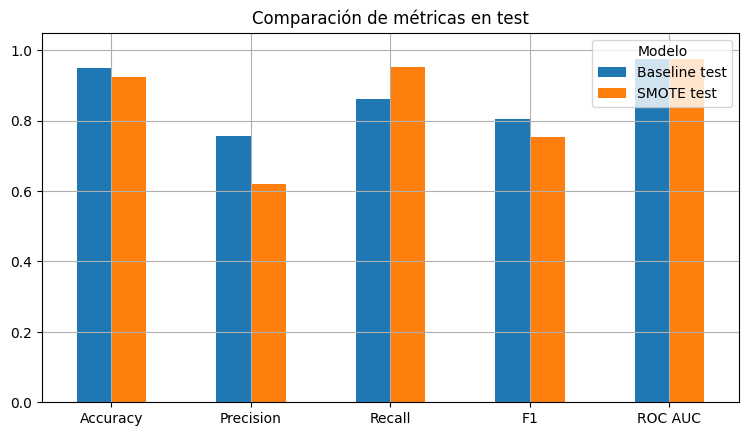

In [12]:
# Compara métricas baseline vs SMOTE
comparison_test = pd.DataFrame([baseline_test, smote_test]).set_index("Modelo")
display(comparison_test.round(4))

comparison_test.T.plot(kind="bar", figsize=(9, 4.8))
plt.title("Comparación de métricas en test")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

### Responde con base en los resultados:

1. ¿qué pasó con  **accuracy** después de aplicar SMOTE?
2. ¿qué pasó con  **recall** de la clase minoritaria?
3. Si el costo de no detectar churn es alto, ¿qué modelo elegirías y por qué?

**Respuestas — Resultados baseline vs SMOTE**

1. **Accuracy:** suele bajar un poco con SMOTE, porque el modelo deja de "acertar fácil" prediciendo siempre la clase mayoritaria.
2. **Recall de la clase minoritaria:** sube, que es el objetivo de SMOTE: al equilibrar las clases en el entrenamiento, el modelo detecta más casos reales de churn.
3. **Si el costo de no detectar churn es alto:** se elige el modelo con SMOTE, porque prioriza el recall (detectar abandonos) aunque pierda algo de accuracy y precision. Perder un cliente cuesta más que una falsa alarma.


## 5. Aprendizaje no supervisado: PCA + KMeans

Ahora ignoramos la variable `churn` para estudiar si existen grupos naturales de clientes.
Luego compararemos esos grupos con la tasa de churn observada.

Varianza explicada por 2 componentes: 0.4799


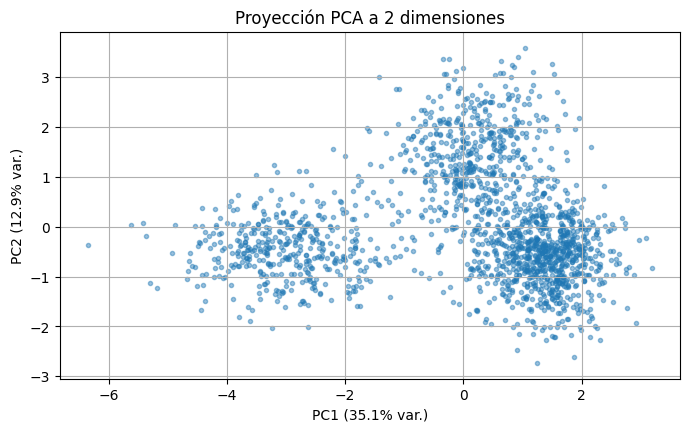

In [13]:
# PCA: reduce a 2 dimensiones para visualizar
X_unsup = df[feature_cols]
X_encoded = preprocessor.fit_transform(X_unsup)
if hasattr(X_encoded, "toarray"):
    X_encoded = X_encoded.toarray()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_encoded)

print("Varianza explicada por 2 componentes:", round(pca.explained_variance_ratio_.sum(), 4))

plt.scatter(X_pca[:, 0], X_pca[:, 1], s=9, alpha=0.45)
plt.title("Proyección PCA a 2 dimensiones")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.show()

,k,inertia,silhouette
0,2,3477.745518,0.580436
1,3,1629.081438,0.561435
2,4,1371.738313,0.430125
3,5,1153.604195,0.359706


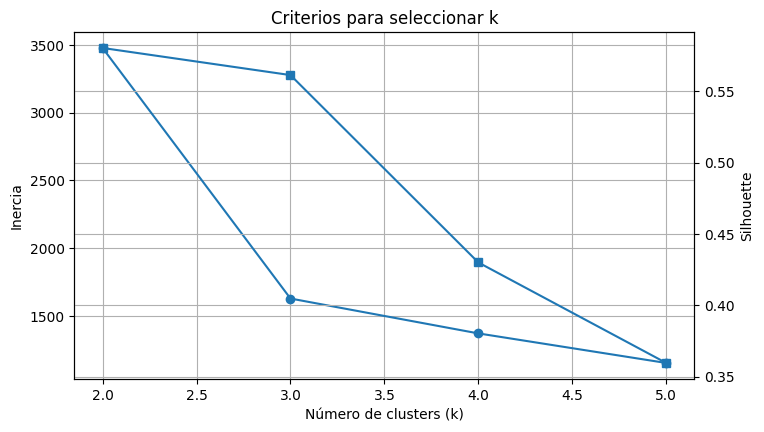

In [14]:
# Elige k: codo (inercia) y silhouette
scores = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append((k, km.inertia_, score))

selection_df = pd.DataFrame(scores, columns=["k", "inertia", "silhouette"])
display(selection_df)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(selection_df["k"], selection_df["inertia"], marker="o")
ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")

ax2 = ax1.twinx()
ax2.plot(selection_df["k"], selection_df["silhouette"], marker="s")
ax2.set_ylabel("Silhouette")
plt.title("Criterios para seleccionar k")
plt.show()

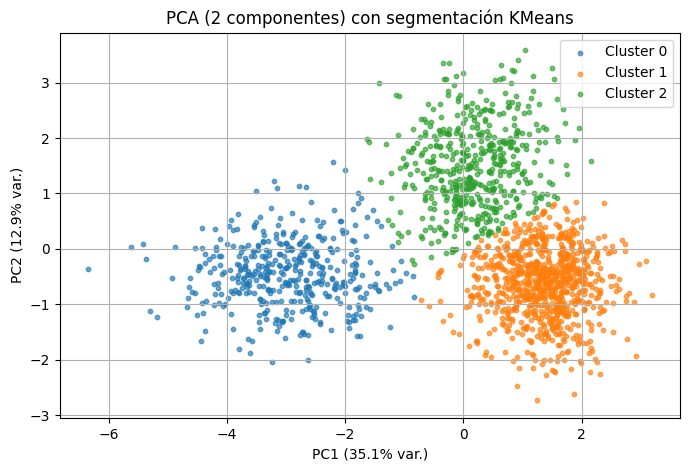

In [15]:
# KMeans con k=3 sobre la proyección PCA
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans.fit_predict(X_pca)

cluster_names = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2"}

plt.figure(figsize=(8, 5))
for c in sorted(np.unique(clusters)):
    mask = clusters == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.65, label=cluster_names[c])

plt.title("PCA (2 componentes) con segmentación KMeans")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.legend()
plt.show()

In [16]:
# Perfil promedio de cada cluster + su tasa de churn
df_clusters = df.copy()
df_clusters["cluster"] = clusters

cluster_profile = df_clusters.groupby("cluster")[[
    "tenure_months", "monthly_spend", "support_tickets", "late_payments",
    "num_logins_30d", "satisfaction_score", "streaming_hours_week", "churn"
]].mean().round(2)

cluster_sizes = df_clusters["cluster"].value_counts().sort_index().rename("size")
display(cluster_sizes.to_frame())
display(cluster_profile)

,size
cluster,
0,427
1,872
2,501


,tenure_months,monthly_spend,support_tickets,late_payments,num_logins_30d,satisfaction_score,streaming_hours_week,churn
cluster,,,,,,,,
0,11.53,80.71,4.06,1.99,11.00,5.09,5.05,0.5
1,33.95,49.33,1.26,0.36,22.46,8.16,9.05,0.0
2,15.43,65.66,2.03,0.69,28.41,6.89,13.01,0.0


### Interpretación final
Con tus resultados, asigna una etiqueta de negocio a cada cluster, por ejemplo:

- **digital activo**,
- **leal estable**,
- **riesgo alto**.

Justifica la etiqueta usando variables promedio y tasa de churn.

**Respuestas — Interpretación de clusters**

Etiquetas típicas según el perfil promedio y la tasa de churn de cada grupo:

- **Leal estable:** alta antigüedad (`tenure_months`), pocos `support_tickets` y `late_payments`, satisfacción alta y churn bajo.
- **Digital activo:** muchos logins y horas de streaming, gasto medio-alto, churn intermedio.
- **Riesgo alto:** baja antigüedad, muchos tickets y pagos atrasados, satisfacción baja y la mayor tasa de churn.

La etiqueta se justifica comparando las medias de cada variable entre clusters y la columna `churn` del perfil.


## 6. Conclusiones esperadas

- El dataset presenta un desbalance importante y accuracy por sí sola no basta.
- **SMOTE** suele mejorar la recuperación de la clase minoritaria.
- **PCA + KMeans** permite descubrir segmentos con perfiles claramente distintos.
- Un cluster con baja antigüedad, más tickets y más pagos atrasados suele concentrar el mayor riesgo de churn.